# Running your first serverless AIFS forecast on Modal

This notebook shows a serverless approach to run [the Artificial Intelligence Forecasting System (AIFS) model](https://huggingface.co/ecmwf/aifs-single-1.1) on [Modal](https://modal.com), using [Icechunk](https://github.com/earth-mover/icechunk) as storage engine to manage initial conditions and forecast outputs arrays on a [Tigris storage backend](https://www.tigrisdata.com).

In [ ]:
import datetime as dt
import os
import time

import icechunk
import matplotlib.pyplot as plt
import plot_utils
import seaborn as sns
import xarray as xr
import zarr

from aifs_modal import app, ingest, run_forecast

The main parameters that we need to define are the start date for the forecast and the desired lead time:

In [ ]:
# start_date = dt.datetime.fromisoformat("2026-02-16T06:00:00+00:00")
# start_date = OpendataClient().latest().replace(tzinfo=dt.UTC)
start_date = dt.datetime(2026, 3, 16, 0, 0, tzinfo=dt.timezone.utc)
print(f"Start date: {start_date}")
lead_time = 96  # in hours

# storage parameters
storage_bucket = "aifs-modal"
# initial conditions
initial_conditions_prefix = "aifs-initial-conditions"
initial_conditions_branch = "main"

Start date: 2026-03-16 00:00:00+00:00


## Ingesting initial conditions into an icechunk repository

In order to be able to run a forecast, we first need to ensure that the initial conditions data for the given dates is available in the initial conditions icechunk repository. Let us first set up the connection to the repository, which is hosted to a [S3-like bucket from Tigris](https://www.tigrisdata.com):

In [ ]:
initial_conditions_storage = icechunk.tigris_storage(
    bucket=storage_bucket,
    prefix=initial_conditions_prefix,
    region=os.getenv("AWS_REGION", None),
    access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
)
initial_conditions_repo = icechunk.Repository.open_or_create(initial_conditions_storage)

  2026-03-18T13:08:29.900307Z  WARN aws_runtime::env_config::normalize: profile [plugins] ignored; sections in the AWS config file (other than [default]) must have a prefix i.e. [profile my-profile]
    at /home/conda/feedstock_root/build_artifacts/icechunk_1773674412996/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.5.18/src/env_config/normalize.rs:121



Now, we will ensure that the initial conditions data for the target and previous (6h before) date:

In [ ]:
for date in [start_date - dt.timedelta(hours=6), start_date]:
    ingest.ensure_date_ingested(
        date, initial_conditions_repo, branch=initial_conditions_branch
    )

Initial conditions already ingested for 2026-03-15T18:00:00+00:00 (group: 2026-03-15/18z); skipping
Initial conditions already ingested for 2026-03-16T00:00:00+00:00 (group: 2026-03-16/00z); skipping


## Deterministic forecast (AIFS-Single)

The [AIFS-Single](https://huggingface.co/ecmwf/aifs-single-1.1) model produces a single deterministic forecast. We run it on Modal and store the outputs in the `aifs-outputs` prefix.

Note that depending on your connectivity, ingestion can take a while. However, as noted [in the "Running AI Weather Forecasts in the Cloud with ECMWF AIFS, Earthmover, and Coiled" webinar](https://earthmover.io/blog/the-3-key-optimizations-that-cut-the-cost-of-ai-weather-forecasts-by-90), most of this time is spent downloading and parsing GRIB files, a process **which does not require GPU use** and thus is run locally in the present notebook.

In [ ]:
# run a single (deterministic) forecast on modal
single_outputs_prefix = "aifs-outputs-single"
single_outputs_branch = "main"
# with modal.enable_output():
with app.run():
    _start = time.perf_counter()
    run_forecast.remote(
        start_date,
        storage_bucket,
        lead_time=lead_time,
        initial_conditions_prefix=initial_conditions_prefix,
        initial_conditions_branch=initial_conditions_branch,
        outputs_prefix=single_outputs_prefix,
        outputs_branch=single_outputs_branch,
    )
    print(
        f"Ran {lead_time}-hour deterministic forecast in "
        f"{time.perf_counter() - _start:.1f}s"
    )

Ran 96-hour deterministic forecast in 148.7s


Once the forecast is done, we can read it from the outputs icechunk repository:

In [ ]:
outputs_storage = icechunk.tigris_storage(
    bucket=storage_bucket,
    prefix=single_outputs_prefix,
    region=os.getenv("AWS_REGION", None),
    access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
)
outputs_repo = icechunk.Repository.open(outputs_storage)
# here we just need to read data
outputs_session = outputs_repo.readonly_session(single_outputs_branch)
outputs_root = zarr.open_group(outputs_session.store, mode="r", zarr_format=3)

  2026-03-18T13:11:10.195998Z  WARN aws_runtime::env_config::normalize: profile [plugins] ignored; sections in the AWS config file (other than [default]) must have a prefix i.e. [profile my-profile]
    at /home/conda/feedstock_root/build_artifacts/icechunk_1773674412996/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.5.18/src/env_config/normalize.rs:121



We can first see the dates for which we have forecast outputs stored:

In [ ]:
# forecasts = ["00z", "06z", "12z", "18z"]
dates = list(outputs_root.group_keys())
dates.sort(reverse=True)
print(dates)

['2026-03-16']


read the data into an xarray data set:

In [ ]:
date_group = outputs_root[dates[0]]
times = sorted(date_group.group_keys())
forecast_group = f"{dates[0]}/{times[0]}"
forecast_ds = xr.open_dataset(
    outputs_session.store,
    group=forecast_group,
    engine="zarr",
    zarr_format=3,
    chunks=None,
)
forecast_ds

<xarray.Dataset> Size: 2GB
Dimensions:     (valid_time: 16, lat: 721, lon: 1440, pressure: 13)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 128B 2026-03-16T06:00:00 ... 2026...
  * lat         (lat) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon         (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
  * pressure    (pressure) int64 104B 50 100 150 200 250 ... 700 850 925 1000
Data variables: (12/24)
    100u        (valid_time, lat, lon) float32 66MB ...
    100v        (valid_time, lat, lon) float32 66MB ...
    10v         (valid_time, lat, lon) float32 66MB ...
    2d          (valid_time, lat, lon) float32 66MB ...
    10u         (valid_time, lat, lon) float32 66MB ...
    hcc         (valid_time, lat, lon) float32 66MB ...
    ...          ...
    tp          (valid_time, lat, lon) float32 66MB ...
    stl1        (valid_time, lat, lon) float32 66MB ...
    strd        (valid_time, lat, lon) float32 66MB ...
    swvl1       (valid_time, lat, lon) float32 66MB ...
    swvl2       (valid_time, lat, lon) float32 66MB ...
    tcw         (valid_time, lat, lon) float32 66MB ...

and now let xarray take it from here, again, running locally **without the need of any GPU**:

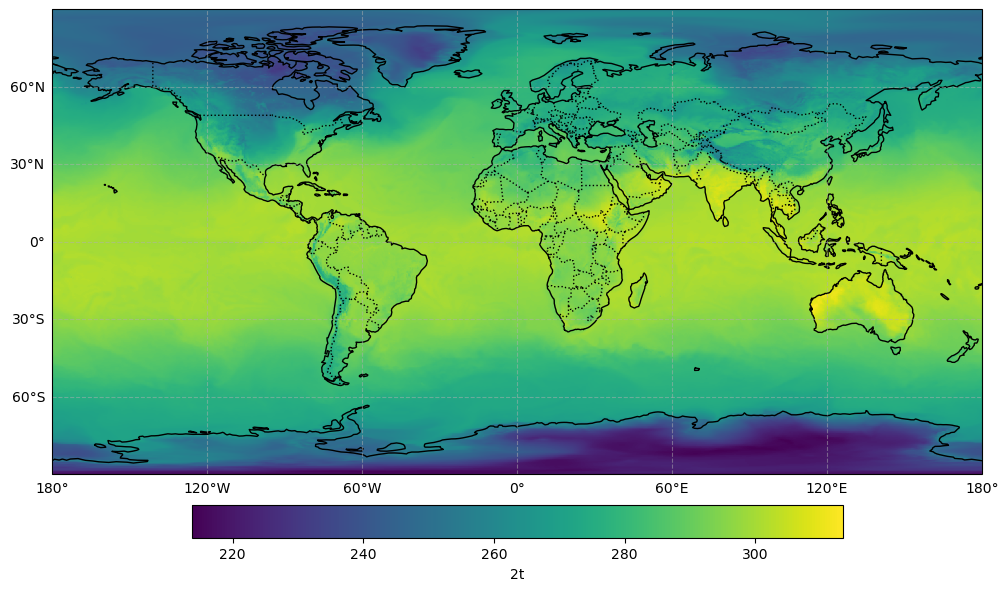

In [ ]:
# plot a given variable
variable = "2t"
_ = plot_utils.make_cartopy_plot(forecast_ds[variable].isel(valid_time=0))

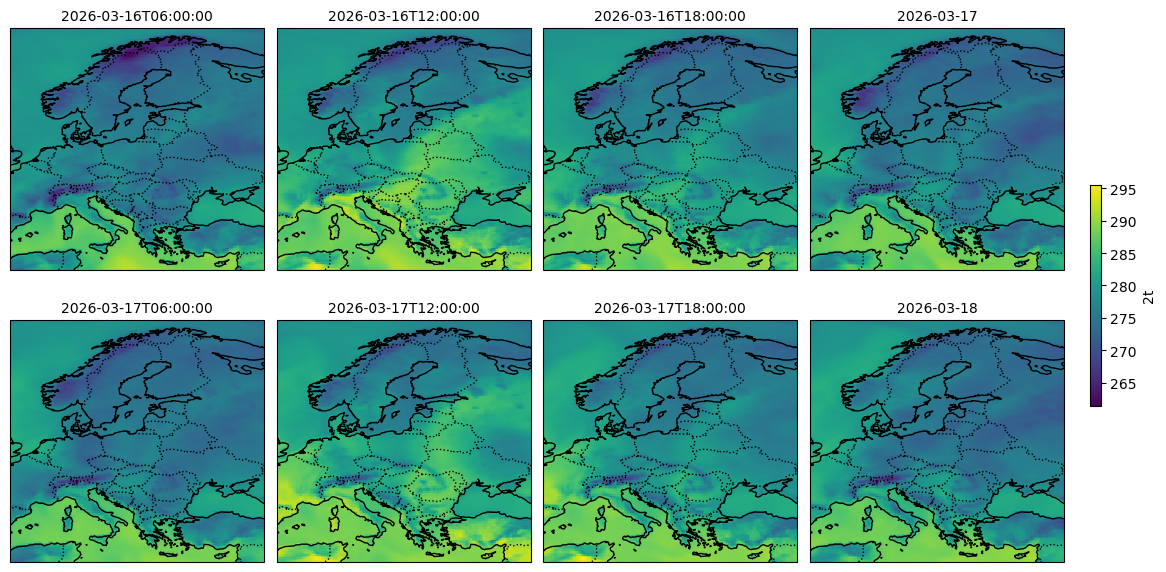

In [ ]:
# plot forecasts for a limited region, e.g., Europe
lat_slice = slice(72, 34)
lon_slice = slice(0, 40)
time_islice = slice(0, 8)
g = plot_utils.make_cartopy_facet_plot(
    forecast_ds[variable]
    .sel(lat=lat_slice, lon=lon_slice)
    .isel(valid_time=time_islice),
    cbar_kwargs={"shrink": 0.4, "pad": 0.02},
)
g.set_titles("{value}")

## Ensemble forecast (AIFS-ENS)

The [AIFS-ENS](https://huggingface.co/ecmwf/aifs-ens-1.0) model produces probabilistic forecasts: each member applies stochastic perturbations via a different random seed, yielding a distribution of plausible outcomes from the same initial conditions. We run all members sequentially on a single GPU and store them in the `aifs-outputs-ens` prefix under `<date>/member_XX` sub-groups:

In [ ]:
n_members = 10
ens_outputs_prefix = "aifs-outputs-ens"
ens_outputs_branch = "main"

# with modal.enable_output():
with app.run():
    _start = time.perf_counter()
    run_forecast.remote(
        start_date,
        storage_bucket,
        lead_time=lead_time,
        initial_conditions_prefix=initial_conditions_prefix,
        initial_conditions_branch=initial_conditions_branch,
        outputs_prefix=ens_outputs_prefix,
        outputs_branch=ens_outputs_branch,
        n_members=n_members,
    )
    print(
        f"Ran {lead_time}-hour ensemble forecast sequentially with {n_members} for "
        f"{lead_time} hours in {time.perf_counter() - _start:.1f}s"
    )

Ran 96-hour ensemble forecast sequentially with 10 for 96 hours in 454.4s


```{note}
Note that this notebook runs ensemble members **sequentially on a single GPU** via `run_forecast` with `n_members`. For real world use cases, it may be better to use `run_ensemble_forecast` to run members **in parallel on separate GPUs** using icechunk's fork/merge pattern — see the [How it works](../how-it-works.md) page for architecture diagrams and the [heatwave reforecast notebook](heatwave-reforecast-ens.ipynb) for a practical example.
```

We can now load the ensemble forecast from the outputs storage:

In [ ]:
ens_outputs_storage = icechunk.tigris_storage(
    bucket=storage_bucket,
    prefix=ens_outputs_prefix,
    region=os.getenv("AWS_REGION", None),
    access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
)
ens_outputs_repo = icechunk.Repository.open(ens_outputs_storage)
ens_outputs_session = ens_outputs_repo.readonly_session(ens_outputs_branch)

ens_forecast_group = start_date.strftime("%Y-%m-%d/%Hz")
ens_forecast_ds = xr.open_dataset(
    ens_outputs_session.store,
    group=ens_forecast_group,
    engine="zarr",
    zarr_format=3,
    chunks=None,
)
ens_forecast_ds

  2026-03-17T11:13:04.064906Z  WARN aws_runtime::env_config::normalize: profile [plugins] ignored; sections in the AWS config file (other than [default]) must have a prefix i.e. [profile my-profile]
    at /home/conda/feedstock_root/build_artifacts/icechunk_1773674412996/_build_env/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-runtime-1.5.18/src/env_config/normalize.rs:121



<xarray.Dataset> Size: 15GB
Dimensions:          (ensemble_member: 10, valid_time: 16, lat: 721, lon: 1440,
                      pressure: 13)
Coordinates:
  * ensemble_member  (ensemble_member) int64 80B 0 1 2 3 4 5 6 7 8 9
  * valid_time       (valid_time) datetime64[ns] 128B 2026-03-16T06:00:00 ......
  * lat              (lat) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * lon              (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * pressure         (pressure) int64 104B 50 100 150 200 ... 700 850 925 1000
Data variables: (12/22)
    100v             (ensemble_member, valid_time, lat, lon) float32 664MB ...
    100u             (ensemble_member, valid_time, lat, lon) float32 664MB ...
    2d               (ensemble_member, valid_time, lat, lon) float32 664MB ...
    cp               (ensemble_member, valid_time, lat, lon) float32 664MB ...
    10v              (ensemble_member, valid_time, lat, lon) float32 664MB ...
    2t               (ensemble_member, valid_time, lat, lon) float32 664MB ...
    ...               ...
    strd             (ensemble_member, valid_time, lat, lon) float32 664MB ...
    stl2             (ensemble_member, valid_time, lat, lon) float32 664MB ...
    sf               (ensemble_member, valid_time, lat, lon) float32 664MB ...
    skt              (ensemble_member, valid_time, lat, lon) float32 664MB ...
    sp               (ensemble_member, valid_time, lat, lon) float32 664MB ...
    stl1             (ensemble_member, valid_time, lat, lon) float32 664MB ...

Plot the ensemble mean and spread alongside the deterministic forecast for the first valid time (note that ensemble aggregations can take a bit to compute):

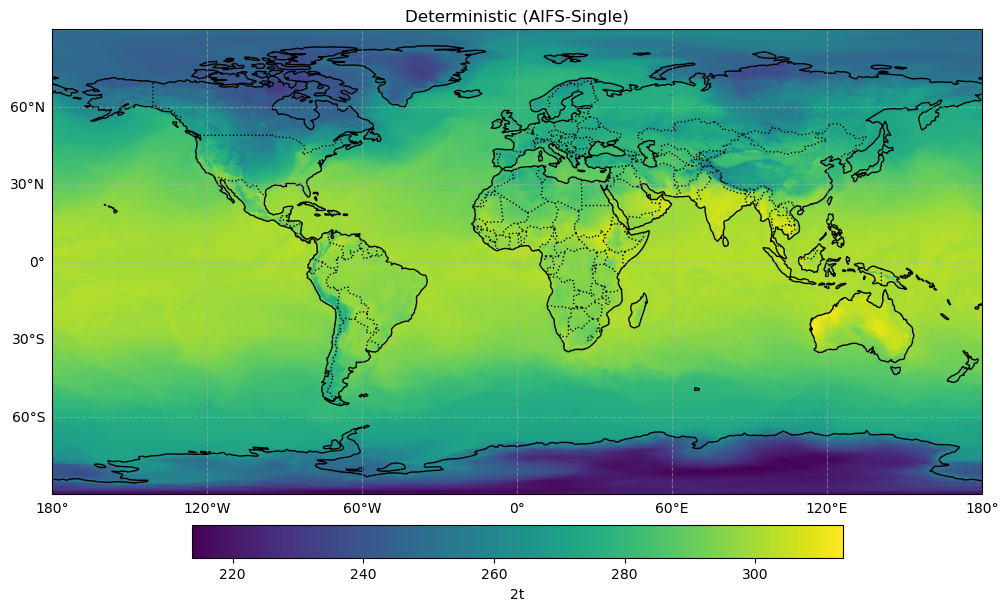

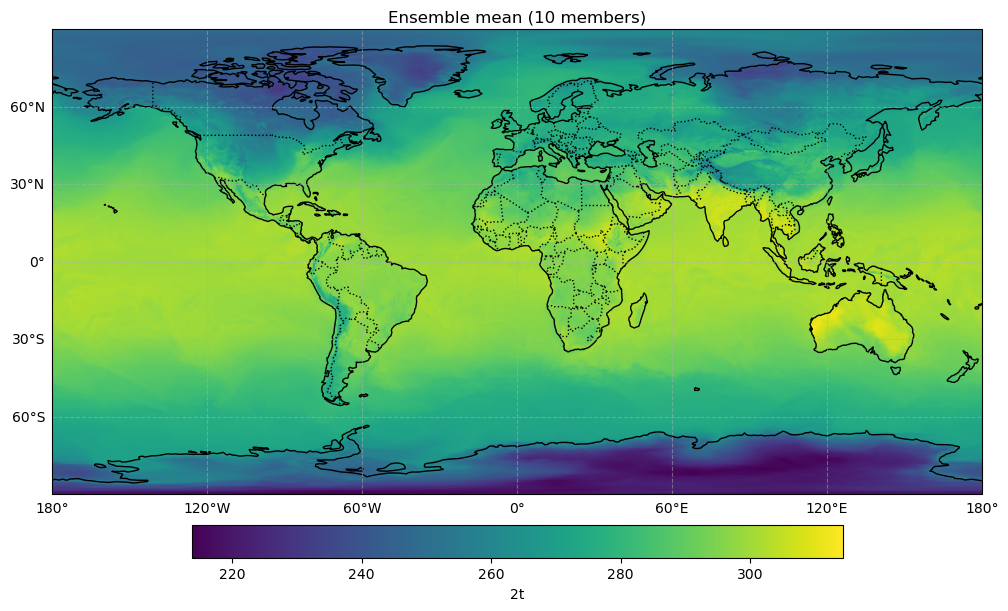

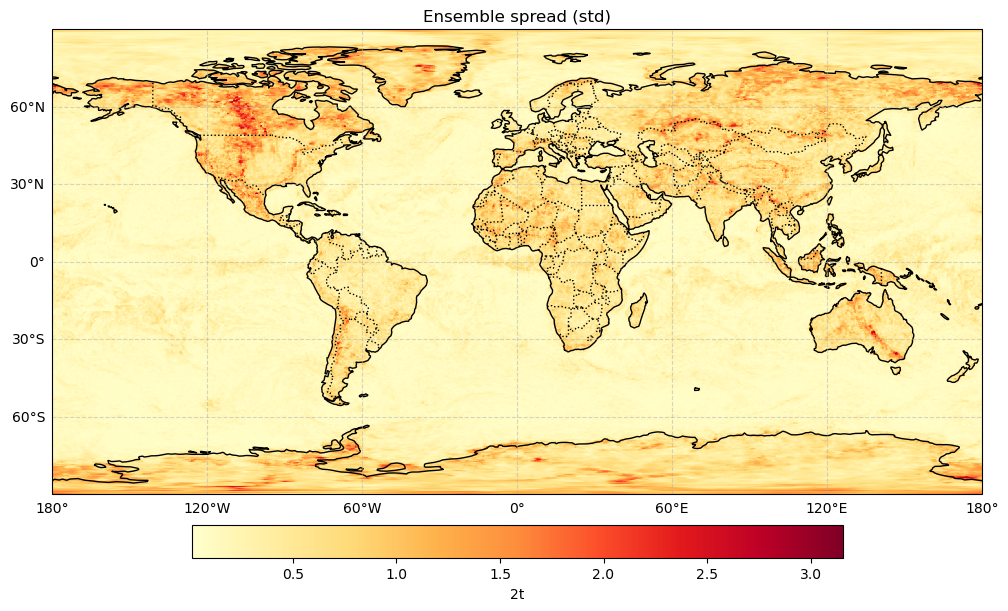

In [ ]:
ens_slice = ens_forecast_ds[variable].isel(valid_time=0)
ens_mean = ens_slice.mean(dim="ensemble_member")
ens_std = ens_slice.std(dim="ensemble_member")
det = forecast_ds[variable].isel(valid_time=0)

for da, title, cmap in zip(
    [det, ens_mean, ens_std],
    [
        "Deterministic (AIFS-Single)",
        f"Ensemble mean ({n_members} members)",
        "Ensemble spread (std)",
    ],
    ["viridis", "viridis", "YlOrRd"],
):
    _ = plot_utils.make_cartopy_plot(
        da,
        cmap=cmap,
        title=title,
    )

Ensemble 2 m temperature time series at Lausanne (46.52°N, 6.63°E), showing individual members, ensemble mean, and 10th–90th percentile envelope:

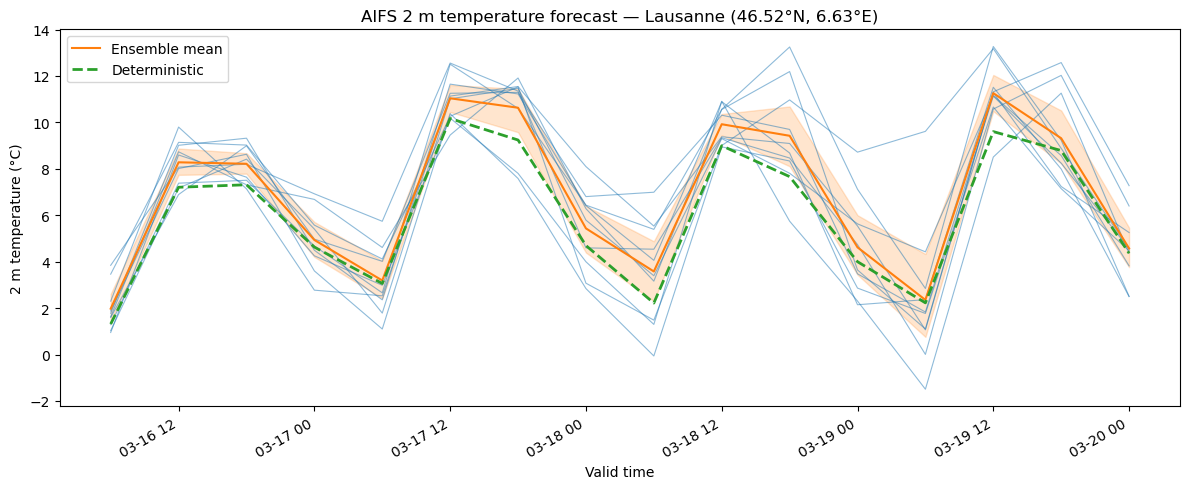

In [ ]:
# Lausanne coordinates
lat, lon = 46.52, 6.63

# extract 2t at nearest grid point for all members, convert to °C
t2m_da = ens_forecast_ds["2t"].sel(lat=lat, lon=lon, method="nearest") - 273.15

# build a long-form dataframe for seaborn
ens_df = t2m_da.to_dataframe(name="2t").reset_index().assign(source="AIFS-ENS member")

# deterministic forecast
det_da = forecast_ds["2t"].sel(lat=lat, lon=lon, method="nearest") - 273.15
det_df = (
    det_da.to_dataframe(name="2t")
    .reset_index()
    .assign(source="AIFS-Single", ensemble_member=-1)
)

# plot_df = pd.concat([ens_df, det_df], ignore_index=True)
# make a wider plot
fig, ax = plt.subplots(figsize=(12, 5))
# default seaborn colors
colors = sns.color_palette()
# plot ensembles without any estimator (thinner lines)
sns.lineplot(
    data=ens_df,
    x="valid_time",
    y="2t",
    units="ensemble_member",
    estimator=None,
    color=colors[0],
    alpha=0.5,
    linewidth=0.8,
    ax=ax,
)
# plot ensembles mean and CI
sns.lineplot(
    data=ens_df,
    x="valid_time",
    y="2t",
    color=colors[1],
    label="Ensemble mean",
    ax=ax,
)
# plot deterministic (dashed thicker line)
sns.lineplot(
    data=det_df,
    x="valid_time",
    y="2t",
    color=colors[2],
    linewidth=2,
    linestyle="--",
    label="Deterministic",
    ax=ax,
)

ax.set_ylabel("2 m temperature (°C)")
ax.set_xlabel("Valid time")
ax.set_title(f"AIFS 2 m temperature forecast — Lausanne ({lat}°N, {lon}°E)")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()